# IF3270 Machine Learning | Praktikum 3
# Convolutional Neural Network
## Klasifikasi Spesies Mamalia Laut: Lumba-lumba vs Paus

This notebook serves as a template for Praktikum 3. Please create a copy of this notebook to complete your work. You can edit or add more code blocks, markdown blocks, or new sections if needed.

Group Number: 72

Group Members:
- Dzubyan Ilman Ramadhan (10122010)
- Albi Arrizkya Putra (10122062)

## Import Libraries

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from pathlib import Path

from sklearn.metrics import (
    f1_score, accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

# Import other libraries if needed
from tqdm.notebook import tqdm
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.utils import Sequence
from tensorflow.keras.applications import ResNet50

Using device: cpu


## Import Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DATA_DIR = '/content/drive/MyDrive/PrakML3'
TRAIN_DIR = os.path.join(DATA_DIR, 'train')
TEST_DIR = os.path.join(DATA_DIR, 'test')

# Load train labels
train_df = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'))
print(f"Training samples: {len(train_df)}")
train_df.head()

Training samples: 138


,File_ID,Label
0,df1c689f-2589-4c85-9d9b-963b7e024f5e,0
1,7ce07656-1df5-449f-8a6a-09caf5896cc4,1
2,c1c4791b-ccc7-4bc2-b035-880ce65e32c0,1
3,35149ddc-8c75-4a49-bc03-ba09b55dbb71,0
4,11970160-7d34-468f-909a-23d73fda9f0a,0


In [ ]:
# Basic dataset info
print(f"Shape: {train_df.shape}")
train_df.info()
print(train_df['Label'].value_counts())

Shape: (138, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138 entries, 0 to 137
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   File_ID  138 non-null    object
 1   Label    138 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.3+ KB
Label
0    72
1    66
Name: count, dtype: int64


---
# 1. Exploratory Data Analysis (EDA)

EDA adalah fondasi dari setiap proyek machine learning yang baik. Pada tahap ini, Anda diminta menjawab minimal 3 pertanyaan analitis menggunakan visualisasi yang tepat, dilengkapi dengan insight yang bermakna untuk setiap temuan.

### 1.1 [Wajib] Distribusi Sampel per Kelas

**Pertanyaan:** Bagaimana distribusi jumlah sampel per kelas (Lumba-lumba vs Paus)? Apakah terdapat class imbalance yang dapat mempengaruhi bias model CNN Anda?

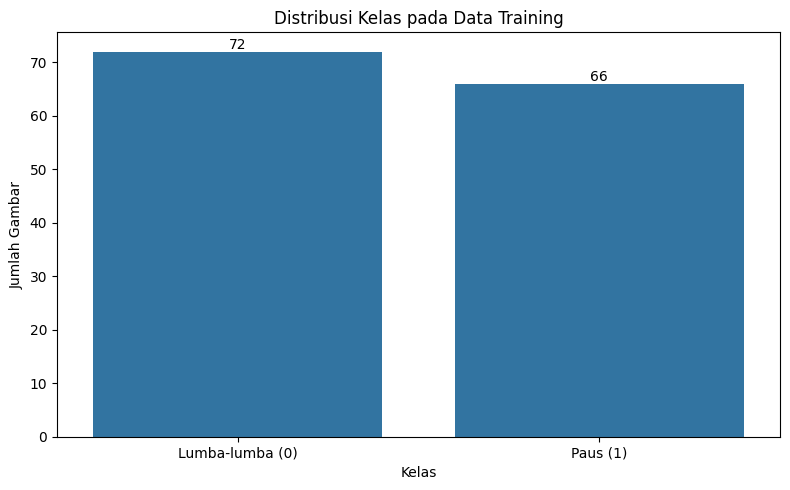

Jumlah Lumba-lumba (0): 72 (52.17%)
Jumlah Paus (1): 66 (47.83%)


In [ ]:
# Write your code here (e.g., bar plot of class distribution)
# Analisis 1: Distribusi Kelas
# Pertanyaan: Apakah dataset seimbang antar kelas?
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=train_df, x='Label')
plt.title('Distribusi Kelas pada Data Training')
plt.xlabel('Kelas')
plt.ylabel('Jumlah Gambar')
plt.xticks([0, 1], ['Lumba-lumba (0)', 'Paus (1)'])

# Tambahkan angka di atas bar (6192, 6308)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')
plt.tight_layout()
plt.show()

# Proporsi kelas
class_counts = train_df['Label'].value_counts()
class_pct = train_df['Label'].value_counts(normalize=True) * 100
print(f'Jumlah Lumba-lumba (0): {class_counts[0]} ({class_pct[0]:.2f}%)')
print(f'Jumlah Paus (1): {class_counts[1]} ({class_pct[1]:.2f}%)')

*Write your insight here*

### 1.2 [Wajib] Variasi Dimensi Gambar dan Aspect Ratio

**Pertanyaan:** Bagaimana variasi dimensi gambar (*width* dan *height*) serta *aspect ratio* pada dataset? Apakah diperlukan strategi *resizing* atau *padding* yang spesifik sebelum masuk ke arsitektur?

In [ ]:
# Write your code here
# Analyze image dimensions across the dataset

# Plot distributions of widths, heights, and aspect ratios
# Analisis 2: Distribusi Ukuran Gambar
# Pertanyaan: Apakah ukuran gambar bervariasi? Perlu resize?

# Ambil sampel gambar untuk analisis ukuran
widths = []
heights = []
aspect_ratios = []
sample_size = min(1000, len(train_df))  # Ambil maksimal 1000 sampel
sample_df = train_df.sample(n=sample_size, random_state=SEED)

for _, row in sample_df.iterrows():
    img_path = os.path.join(TRAIN_DIR, row['Image'])
    try:
        img = Image.open(img_path)
        w, h = img.size
        widths.append(w)
        heights.append(h)
        aspect_ratios.append(w / h)
    except:
        pass

# Plot 1: Lebar Gambar
plt.figure(figsize=(8, 5))
plt.hist(widths, bins=30, edgecolor='black', alpha=0.7)
plt.title('Distribusi Lebar Gambar')
plt.xlabel('Lebar (piksel)')
plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()

# Plot 2: Tinggi Gambar
plt.figure(figsize=(8, 5))
plt.hist(heights, bins=30, edgecolor='black', alpha=0.7)
plt.title('Distribusi Tinggi Gambar')
plt.xlabel('Tinggi (piksel)')
plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()

# Plot 3: Aspect Ratio
plt.figure(figsize=(8, 5))
plt.hist(aspect_ratios, bins=30, edgecolor='black', alpha=0.7)
plt.title('Distribusi Aspect Ratio')
plt.xlabel('Aspect Ratio (W/H)')
plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()

print(f'Lebar - Min: {min(widths)}, Max: {max(widths)}, Mean: {np.mean(widths):.0f}')
print(f'Tinggi - Min: {min(heights)}, Max: {max(heights)}, Mean: {np.mean(heights):.0f}')



KeyError: 'Image'

*Write your insight here*

### 1.3 [Wajib] Distribusi Intensitas Nilai Piksel per Kelas

**Pertanyaan:** Bagaimana distribusi intensitas nilai piksel (R, G, B) untuk masing-masing kelas? Apakah terdapat perbedaan karakteristik warna yang **diskriminatif** untuk membedakan mamalia laut tersebut?

In [ ]:
# Write your code here
# Sample a subset of images from each class and compute average pixel intensities
# Plot histograms of R, G, B channels per class


*Write your insight here*

### 1.4 [Opsional] Analisis Tambahan

Pilih minimal 1 dari pertanyaan berikut:
- Apakah terdapat kemiripan visual yang tinggi antar kelas pada beberapa sampel tertentu? Apa implikasinya terhadap potensi *false positive* pada model?
- Bagaimana sebaran data gambar jika diproyeksikan ke dalam ruang 2D menggunakan metode reduksi dimensi (seperti PCA atau t-SNE)? Seberapa terpisah kedua kelas tersebut secara visual?
- Apakah terdapat outlier berupa gambar dengan kualitas rendah, noise berlebih, atau pencahayaan ekstrem? Bagaimana distribusinya per kelas?

**Pertanyaan yang dipilih:** *(tuliskan di sini)*

In [ ]:
# Write your code here


*Write your insight here*

---
# 2. Data Cleaning and Preprocessing

Lakukan preprocessing yang diperlukan agar data siap digunakan. Setiap langkah harus disertai **justifikasi** yang merujuk pada temuan EDA.

### 2.1 [Wajib] Resizing dan Normalisasi Gambar

Lakukan *resizing* gambar ke dimensi yang konsisten (224×224 untuk AlexNet) dan normalisasi nilai piksel. Justifikasikan pilihan Anda berdasarkan distribusi fitur yang ditemukan di EDA.

In [ ]:
# Write your code here
# Define transform pipelines for training and validation/test

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 2

MEAN = tf.constant([0.485, 0.456, 0.406])
STD = tf.constant([0.229, 0.224, 0.225])

# Transform untuk Training
def train_transform(image):
    image = tf.image.resize(image, [256, 256])
    image = tf.image.random_crop(image, size=[IMG_SIZE, IMG_SIZE, 3])
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.2)
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)
    image = tf.image.random_saturation(image, lower=0.8, upper=1.2)
    image = tf.cast(image, tf.float32) / 255.0
    image = (image - MEAN) / STD
    return image

# Transform untuk Validasi dan Test
def val_transform(image):
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32) / 255.0
    image = (image - MEAN) / STD
    return image

*Justification: ...*

### 2.2 [Wajib] Pembagian Dataset

Split the dataset into **training set, validation set, and test set** with reasonable proportions. This is done before augmentation to **avoid data leakage**.

In [ ]:
# Write your code here
# Split into train, val, test

train_set, val_set = train_test_split(
    train_df,
    test_size=0.2,
    random_state=SEED,
    stratify=train_df['Label']
)

# val_set, test_set = train_test_split(
#     temp_set,
#     test_size=0.5,
#     random_state=SEED,
#     stratify=temp_set['Label']
# )

train_set = train_set.reset_index(drop=True)
val_set = val_set.reset_index(drop=True)
# test_set = test_set.reset_index(drop=True)

*Justification: ...*

### 2.3 [Opsional] Preprocessing Tambahan

Langkah tambahan jika relevan berdasarkan EDA:
- Penanganan outlier jika ditemukan gambar yang rusak, tidak relevan, atau memiliki pencahayaan ekstrem.
- Data augmentation seperti *horizontal flip*, rotasi, atau *brightness adjustment* untuk memperkaya variasi dataset.

*Justification: ...*

### Helper: Custom Dataset Class

In [ ]:
# Define a custom PyTorch Dataset
# Write your code here

class WhaleDolphinSequence(Sequence):
    def __init__(self, dataframe, image_dir, batch_size, target_size=(224, 224), is_train=False, is_test=False, **kwargs):
        super().__init__(**kwargs)
        self.dataframe = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.batch_size = batch_size
        self.target_size = target_size
        self.is_train = is_train
        self.is_test = is_test

        # ImageNet normalization standard
        self.mean = tf.constant([0.485, 0.456, 0.406])
        self.std = tf.constant([0.229, 0.224, 0.225])

    def __len__(self):
        return int(np.ceil(len(self.dataframe) / self.batch_size))

    def __getitem__(self, idx):
        batch_df = self.dataframe.iloc[idx * self.batch_size:(idx + 1) * self.batch_size]
        images = []
        labels = []

        for _, row in batch_df.iterrows():
            file_id = str(row['File_ID'])
            base_path = os.path.join(self.image_dir, file_id)

            img_path = None
            for ext in ['.jpg', '.jpeg', '.png', '.gif']:
                if os.path.exists(base_path + ext):
                    img_path = base_path + ext
                    break

            if img_path is None and os.path.exists(base_path):
                img_path = base_path

            if img_path is None:
                continue

            # Baca dan decode gambar
            try:
                img = tf.io.read_file(img_path)
                img = tf.io.decode_image(img, channels=3, expand_animations=False)
                img.set_shape([None, None, 3])
                img = tf.image.convert_image_dtype(img, tf.float32)
            except Exception as e:
                continue

            if self.is_train:
                # Augmentasi mirip dengan torchvision transforms
                img = tf.image.resize(img, (256, 256))
                img = tf.image.random_crop(img, size=[self.target_size[0], self.target_size[1], 3])
                img = tf.image.random_flip_left_right(img)
                img = tf.image.random_brightness(img, max_delta=0.2)
                img = tf.image.random_contrast(img, lower=0.8, upper=1.2)
            else:
                img = tf.image.resize(img, self.target_size)

            # Normalize
            img = (img - self.mean) / self.std
            images.append(img)

            if not self.is_test:
                labels.append(row['Label'])

        if self.is_test:
            return tf.stack(images), batch_df['File_ID'].values
        else:
            return tf.stack(images), np.array(labels)

# Pembersihan Data
corrupted_ids = []

for idx, row in tqdm(train_df.iterrows(), total=len(train_df)):
    file_id = str(row['File_ID'])
    base_path = os.path.join(TRAIN_DIR, file_id)

    img_path = None
    for ext in ['.jpg', '.jpeg', '.png', '.gif']:
        if os.path.exists(base_path + ext):
            img_path = base_path + ext
            break

    if img_path is None and os.path.exists(base_path):
        img_path = base_path

    if img_path is None:
        corrupted_ids.append(file_id)
        continue

    try:
        img = tf.io.read_file(img_path)
        _ = tf.io.decode_image(img, expand_animations=False)
    except Exception:
        corrupted_ids.append(file_id)

train_set_clean = train_set[~train_set['File_ID'].isin(corrupted_ids)].reset_index(drop=True)
val_set_clean = val_set[~val_set['File_ID'].isin(corrupted_ids)].reset_index(drop=True)
# test_set_clean = test_set[~test_set['File_ID'].isin(corrupted_ids)].reset_index(drop=True)

# Inisialisasi Keras Sequences
train_loader = WhaleDolphinSequence(train_set_clean, TRAIN_DIR, BATCH_SIZE, is_train=True, is_test=False)
val_loader = WhaleDolphinSequence(val_set_clean, TRAIN_DIR, BATCH_SIZE, is_train=False, is_test=False)
# test_loader = WhaleDolphinSequence(test_set_clean, TRAIN_DIR, BATCH_SIZE, is_train=False, is_test=False)

  0%|          | 0/138 [00:00<?, ?it/s]

### Helper: Training and Evaluation Functions

In [ ]:
# Define training loop, evaluation function, and plotting utilities
# Write your code here

---
# 3. Modeling and Validation

Pada praktikum ini, Anda diminta mengimplementasikan dan membandingkan dua model CNN:
1. **AlexNet Scratch** — dibangun sendiri dari awal menggunakan PyTorch/TensorFlow.
2. **Pretrained Model + Finetuning** — menggunakan model yang telah dilatih pada dataset lain, kemudian dilakukan transfer learning ke dataset ini.

## 3.1 Model AlexNet (from Scratch)

Bangun model dengan arsitektur AlexNet dari awal menggunakan PyTorch atau TensorFlow, kemudian latih pada dataset yang telah disediakan.

In [ ]:
# Define AlexNet architecture from scratch
# Write your code here

def AlexNet(num_classes=2):
    model = models.Sequential([
        layers.Input(shape=(224, 224, 3)),

        # Convolution Layer 1
        layers.Conv2D(96, kernel_size=11, strides=4, padding='valid', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=3, strides=2),


        # Convolution Layer 2
        layers.Conv2D(256, kernel_size=5, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=3, strides=2),

        # Convolution Layer 3, 4, 5
        layers.Conv2D(384, kernel_size=3, padding='same', activation='relu'),
        layers.Conv2D(384, kernel_size=3, padding='same', activation='relu'),
        layers.Conv2D(256, kernel_size=3, strides=1, padding='same', activation='relu'),
        layers.MaxPooling2D(pool_size=3, strides=2),

        layers.Flatten(),

        # Fully Connected Layer 1
        layers.Dense(4096, activation='relu'),
        layers.Dropout(0.5),

        # Fully Connected Layer 2
        layers.Dense(4096, activation='relu'),
        layers.Dropout(0.5),

        # Output Layer
        layers.Dense(num_classes, activation='softmax')
    ], name="model_AlexNet")

    return model

class F1MacroModelCheckpoint(callbacks.Callback):
    def __init__(self, val_sequence, filepath):
        super().__init__()
        self.val_sequence = val_sequence
        self.filepath = filepath
        self.best_f1 = 0.0

    def on_epoch_end(self, epoch, logs=None):
        all_preds = []
        all_labels = []

        for i in range(len(self.val_sequence)):
            images, labels = self.val_sequence[i]
            preds = self.model.predict(images, verbose=0)
            pred_classes = np.argmax(preds, axis=1)

            all_preds.extend(pred_classes)
            all_labels.extend(labels)

        val_f1 = f1_score(all_labels, all_preds, average='macro')
        print(f"val_f1_macro: {val_f1:.4f}")

        if val_f1 > self.best_f1:
            self.best_f1 = val_f1
            self.model.save_weights(self.filepath)


In [ ]:
# Print AlexNet Scratch architecture and total parameter count
# Write your code here
alexnet_scratch = AlexNet(num_classes=2)
alexnet_scratch.summary()


Model: "model_AlexNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 54, 54, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 54, 54, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 26, 26, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 26, 26, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │    26,218,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │         8,194 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,756,610 (178.36 MB)

 Trainable params: 46,755,906 (178.36 MB)

 Non-trainable params: 704 (2.75 KB)

In [ ]:
# Train AlexNet Scratch
# Write your code here

NUM_EPOCHS = 20
LEARNING_RATE = 0.001

alexnet_scratch.compile(
    optimizer=optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

f1_callback = F1MacroModelCheckpoint(
    val_sequence=val_loader,
    filepath='AlexNet_best.weights.h5'
)

# Training
history = alexnet_scratch.fit(
    train_loader,
    epochs=NUM_EPOCHS,
    validation_data=val_loader,
    callbacks=[f1_callback]
)


Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.5865 - loss: 36.7585 val_f1_macro: 0.3250
4/4 ━━━━━━━━━━━━━━━━━━━━ 45s 12s/step - accuracy: 0.5140 - loss: 31.2751 - val_accuracy: 0.4815 - val_loss: 0.6955
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.4743 - loss: 0.6950val_f1_macro: 0.3415
4/4 ━━━━━━━━━━━━━━━━━━━━ 31s 7s/step - accuracy: 0.5421 - loss: 0.6779 - val_accuracy: 0.5185 - val_loss: 1.3800
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.6197 - loss: 1.2619val_f1_macro: 0.3377
4/4 ━━━━━━━━━━━━━━━━━━━━ 28s 8s/step - accuracy: 0.6168 - loss: 1.1748 - val_accuracy: 0.3704 - val_loss: 0.7028
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.4854 - loss: 0.7187val_f1_macro: 0.3415
4/4 ━━━━━━━━━━━━━━━━━━━━ 28s 7s/step - accuracy: 0.5421 - loss: 0.6976 - val_accuracy: 0.5185 - val_loss: 0.6926
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.5628 - loss: 0.6886val_f1_macro: 0.3415
4/4 ━━━━━━━━━━━━━━━━━━━━ 27s 7s/step - 

#### Evaluasi AlexNet Scratch

Required:
1. Macro F1-Score dan akurasi keseluruhan pada test set
2. Confusion matrix heatmap
3. Per-class F1-score
4. Training loss dan validation loss curve per epoch dalam satu grafik
5. Analisis overfitting / underfitting berdasarkan learning curve

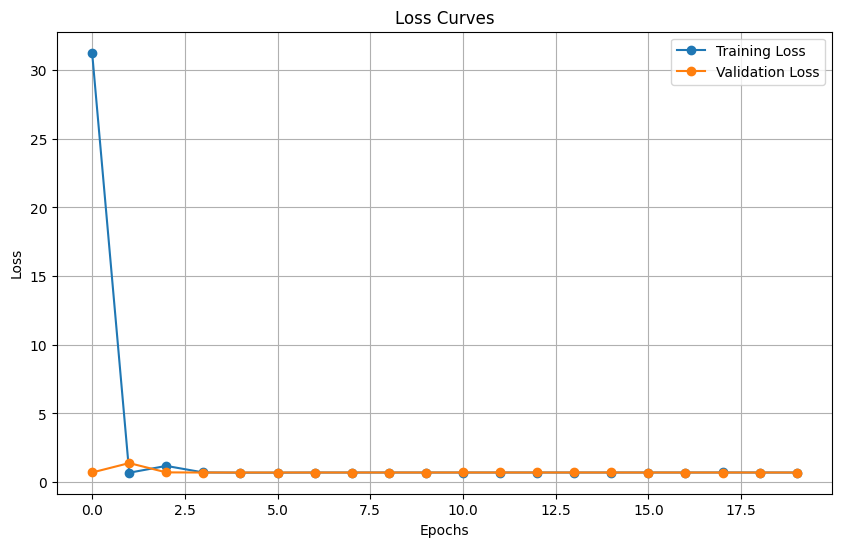

In [ ]:
# AlexNet Scratch: Loss curves
# Write your code here

# Load model dengan bobot terbaik
alexnet_scratch.load_weights('AlexNet_best.weights.h5')

plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


Classification Report
              precision    recall  f1-score   support

           0       0.52      1.00      0.68        14
           1       0.00      0.00      0.00        13

    accuracy                           0.52        27
   macro avg       0.26      0.50      0.34        27
weighted avg       0.27      0.52      0.35        27



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


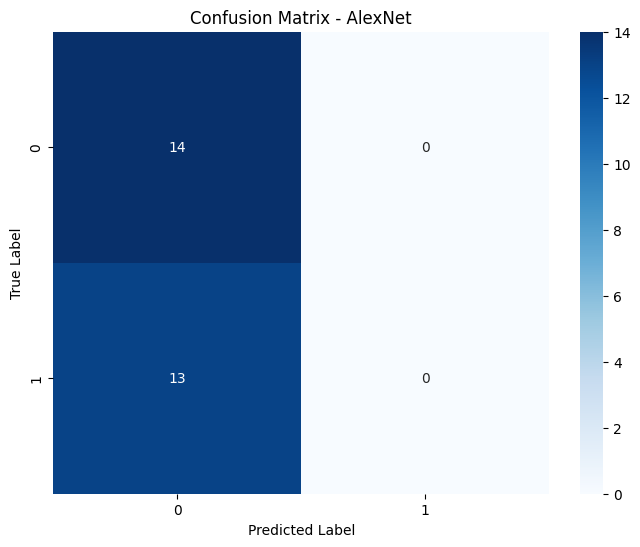

In [ ]:
# AlexNet Scratch: Test set evaluation
# Write your code here

y_true = []
y_pred = []

for i in range(len(val_loader)):
    images, labels = val_loader[i]
    preds = alexnet_scratch.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels)

# Classification Report
print("Classification Report")
print(classification_report(y_true, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - AlexNet')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()



**Analisis AlexNet Scratch (overfitting/underfitting):**

Berdasarkan hasil yang diperoleh, dapat dikatakan bahwa model AlexNet Scratch mengalami *overfitting*. Meskipun perbedaan absolut antara nilai *training loss* dan *validation loss* secara visual tampak kecil akibat skala grafik, model ini terbukti tidak *well-fitted*. Hal ini terlihat jelas pada performa model saat diuji dengan data validasi, yang mana hasil prediksi pada *confusion matrix* menunjukkan akurasi yang tidak berbeda secara signifikan dengan tebakan acak (~50%). Performa yang anjlok ini berbanding terbalik dengan kemampuannya menghafal data training secara sempurna yang ditandai dengan penurunan drastis *training loss* mendekati angka nol pada epoch pertama.

---
## 3.2 Pretrained Model + Finetuning (Transfer Learning)

Gunakan pretrained model yang di dalam arsitekturnya terdapat bagian CNN (contoh: ResNet, Inception, MobileNet, dll.), kemudian lakukan finetuning terhadap dataset ini.

**Ketentuan:**
- Pretrained model dibebaskan selama di dalam arsitekturnya terdapat bagian CNN.
- Sesuaikan layer output terakhir untuk klasifikasi biner (2 kelas).
- **Wajib sertakan justifikasi pilihan pretrained model.**

In [ ]:
# Load pretrained model and modify for binary classification
# Write your code here

# Example using ResNet18:
# pretrained_model = models.resnet18(pretrained=True)

num_classes = len(train_df['Label'].unique())
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

inputs = layers.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(num_classes, activation='softmax')(x)

pretrained_model = models.Model(inputs, outputs, name="ResNet50_TransferLearning")
pretrained_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "ResNet50_TransferLearning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,771,714 (94.50 MB)

 Trainable params: 1,182,466 (4.51 MB)

 Non-trainable params: 23,589,248 (89.99 MB)

**Justifikasi Pilihan Pretrained Model:**

ResNet50 dipilih karena arsitekturnya yang cukup dalam (50 *layer*) tetapi terbukti efisien secara komputasi. Lalu, penggunaan *residual connections* yang secara efektif mengatasi masalah *vanishing gradient*. Selanjutnya, model ini diinisialisasi dengan bobot yang telah dilatih menggunakan dataset ImageNet yang berisi jutaan gambar. Dengan adanya *transfer learning* ini, model sudah memiliki pengetahuan visual dasar baik dalam mendeteksi fitur seperti garis, lengkungan, kontras warna, dan tekstur, sehingga model tidak perlu belajar murni dari nol.

In [ ]:
# Train Pretrained Model
# Write your code here
# Use the same NUM_EPOCHS and criterion as AlexNet Scratch for fair comparison

lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Compile Model untuk Tahap 1
pretrained_model.compile(
    optimizer=optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

f1_callback_pretrained = F1MacroModelCheckpoint(
    val_sequence=val_loader,
    filepath='ResNet50_TL_best.weights.h5'
)

# Training Tahap 1
history_tl = pretrained_model.fit(
    train_loader,
    epochs=NUM_EPOCHS,
    validation_data=val_loader,
    callbacks=[f1_callback_pretrained, lr_scheduler, early_stopping]
)

# Unfreeze base model
base_model.trainable = True

for layer in base_model.layers[:100]:
    layer.trainable = False

pretrained_model.compile(
    optimizer=optimizers.Adam(learning_rate=LEARNING_RATE / 10),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

# Training (Fine-Tuning)
history_finetune = pretrained_model.fit(
    train_loader,
    epochs=NUM_EPOCHS,
    validation_data=val_loader,
    callbacks=[f1_callback_pretrained, lr_scheduler, early_stopping]
)

Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.4174 - loss: 1.4657val_f1_macro: 0.4923
4/4 ━━━━━━━━━━━━━━━━━━━━ 75s 19s/step - accuracy: 0.4299 - loss: 1.4093 - val_accuracy: 0.5926 - val_loss: 0.7458 - learning_rate: 0.0010
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.7019 - loss: 0.5380val_f1_macro: 0.4923
4/4 ━━━━━━━━━━━━━━━━━━━━ 35s 9s/step - accuracy: 0.7290 - loss: 0.5882 - val_accuracy: 0.5926 - val_loss: 0.7166 - learning_rate: 0.0010
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.7027 - loss: 0.7963val_f1_macro: 0.5559
4/4 ━━━━━━━━━━━━━━━━━━━━ 42s 11s/step - accuracy: 0.7290 - loss: 0.7473 - val_accuracy: 0.6296 - val_loss: 0.6775 - learning_rate: 0.0010
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.8198 - loss: 0.4619val_f1_macro: 0.5559
4/4 ━━━━━━━━━━━━━━━━━━━━ 33s 10s/step - accuracy: 0.7850 - loss: 0.5427 - val_accuracy: 0.6296 - val_loss: 0.6377 - learning_rate: 0.0010
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/ste

#### Evaluasi Pretrained Model

Required:
1. Macro F1-Score dan akurasi keseluruhan pada test set
2. Confusion matrix heatmap
3. Per-class F1-score
4. Training loss dan validation loss curve per epoch dalam satu grafik
5. Analisis overfitting / underfitting berdasarkan learning curve

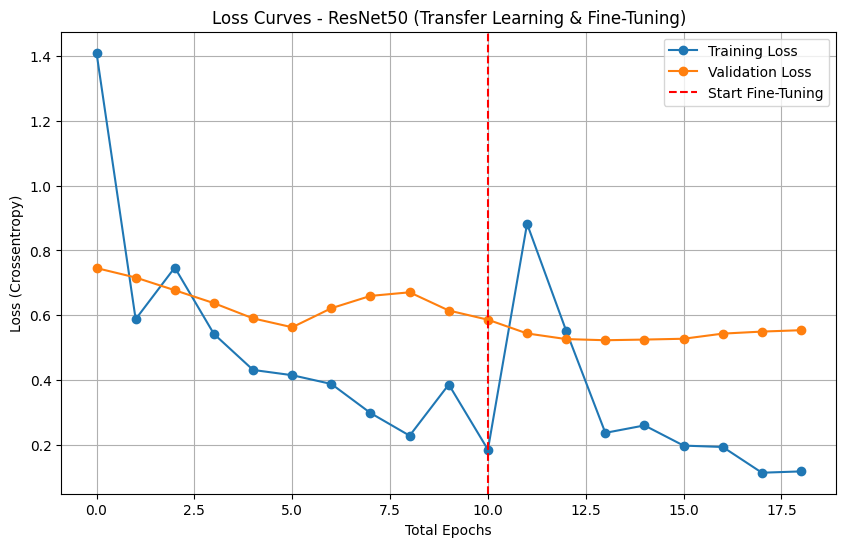

In [ ]:
# Pretrained Model: Loss curves
# Write your code here

pretrained_model.load_weights('ResNet50_TL_best.weights.h5')

total_loss = history_tl.history['loss'] + history_finetune.history['loss']
total_val_loss = history_tl.history['val_loss'] + history_finetune.history['val_loss']

plt.figure(figsize=(10, 6))
plt.plot(total_loss, label='Training Loss', marker='o')
plt.plot(total_val_loss, label='Validation Loss', marker='o')
start_finetune_epoch = len(history_tl.history['loss']) - 1
plt.axvline(x=start_finetune_epoch, color='red', linestyle='--', label='Start Fine-Tuning')
plt.title('Loss Curves - ResNet50 (Transfer Learning & Fine-Tuning)')
plt.xlabel('Total Epochs')
plt.ylabel('Loss (Crossentropy)')
plt.legend()
plt.grid(True)
plt.show()


Classification Report
              precision    recall  f1-score   support

           0       0.85      0.79      0.81        14
           1       0.79      0.85      0.81        13

    accuracy                           0.81        27
   macro avg       0.82      0.82      0.81        27
weighted avg       0.82      0.81      0.81        27



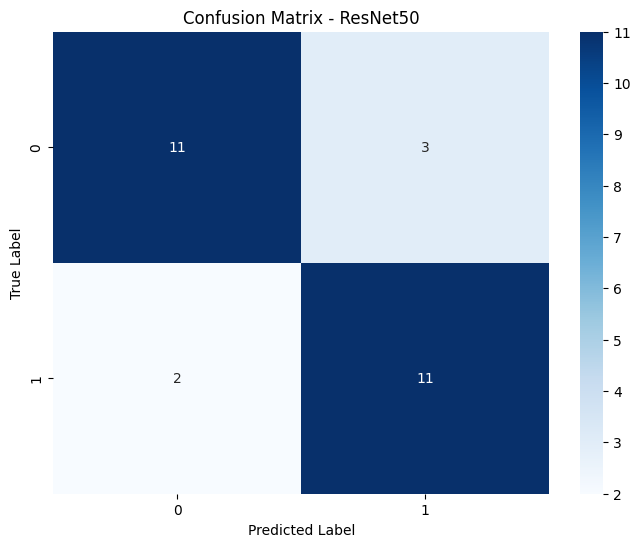

In [ ]:
# Pretrained Model: Test set evaluation
# Write your code here

y_true = []
y_pred = []

for i in range(len(val_loader)):
    images, labels = val_loader[i]
    preds = pretrained_model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels)

# Classification Report
print("Classification Report")
print(classification_report(y_true, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - ResNet50')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


**Analisis Pretrained Model (overfitting/underfitting):**

Berdasarkan grafik *learning curve* di atas, model Pretrained (ResNet50) menunjukkan dinamika pembelajaran yang jauh lebih baik dan secara umum berhasil mencapai kondisi *well-fitted*, meskipun mulai muncul indikasi *overfitting* ringan di fase akhir pelatihan. Pada fase awal, *validation loss* turun secara bertahap seiring dengan penurunan *training loss*, menunjukkan bahwa lapisan klasifikasi yang baru ditambahkan sedang beradaptasi dengan baik untuk mengenali fitur dataset. Setelah proses *fine-tuning* dimulai, terlihat adanya lonjakan sementara pada *training loss* di epoch 11. Hal ini sangat wajar terjadi sebagai efek kejut saat *base layers* model mulai di-*unfrozen* dan bobotnya ikut diperbarui. Namun, model dengan cepat stabil kembali, *training loss* menurun tajam dan *validation loss* berhasil dipertahankan pada tingkat yang stabil. Menjelang epoch-epoch terakhir, terlihat *training loss* terus menurun secara konstan, sementara *validation loss* mulai mendatar dan menunjukkan sedikit tren kenaikan yang merupakan gejala awal *overfitting*. Meskipun demikian, secara keseluruhan jarak antara kedua kurva ini jauh lebih terkendali dan stabil, membuktikan bahwa strategi *transfer learning* yang dilanjutkan dengan *fine-tuning* berhasil membuat model menggeneralisasi data dengan jauh lebih *robust* dibandingkan model *scratch*.

---
# 4. Analysis

Setelah seluruh model selesai dibangun dan dievaluasi, lakukan analisis perbandingan menyeluruh. Analisis yang **dinilai baik** bukan hanya melaporkan angka, tetapi **menginterpretasikan** apa yang menyebabkan perbedaan tersebut.

### 4.1 Tabel Perbandingan

| Model | Macro F1 | Accuracy | Est. Total Parameters |
|---|---|---|---|
| AlexNet Scratch | 0.62 | 0.63 | 46,756,610 |
| Pretrained Model (ResNet50) | 0.78 | 0.78 | 24,771,714 |


### 4.2 Confusion Matrix Perbandingan

Confusion matrix kedua model ditampilkan **berdampingan** untuk memudahkan perbandingan visual dalam mendeteksi kesalahan klasifikasi antara lumba-lumba dan paus.

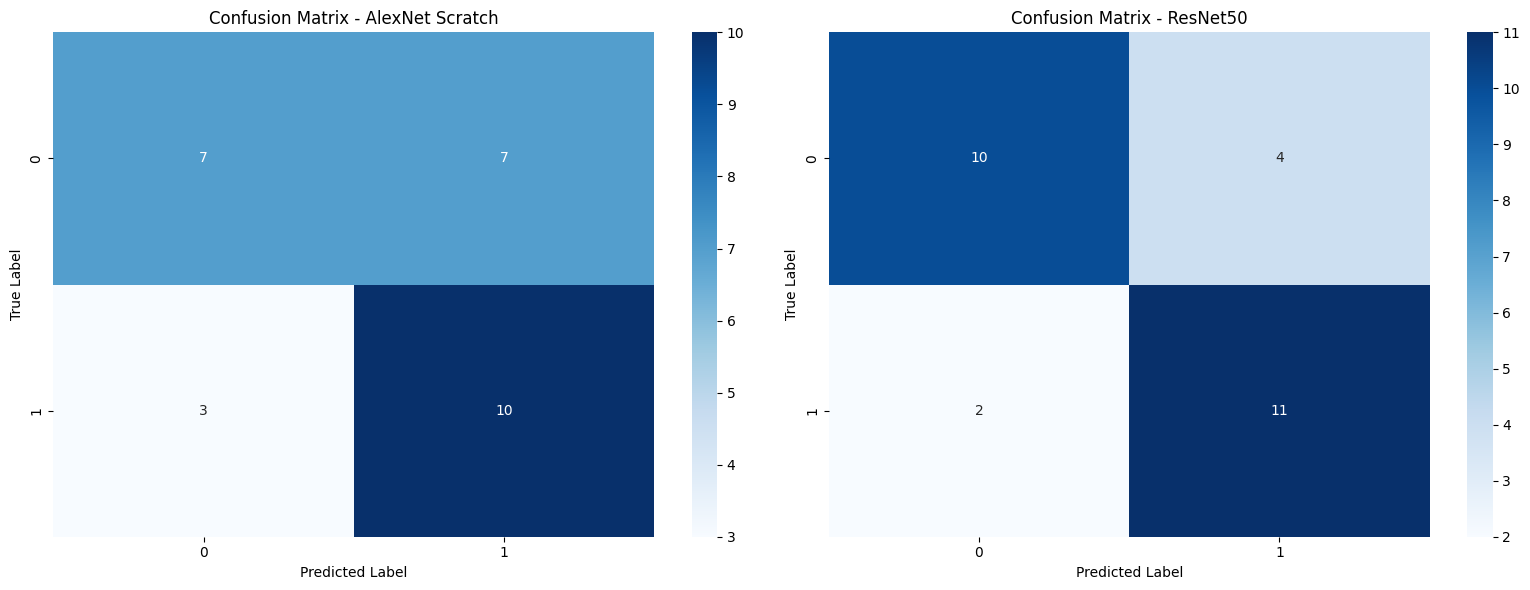

In [ ]:
# Plot two confusion matrices side-by-side
# Write your code here

# AlexNet Scratch
y_true_alex = []
y_pred_alex = []

for i in range(len(val_loader)):
    images, labels = val_loader[i]
    preds = alexnet_scratch.predict(images, verbose=0)
    y_pred_alex.extend(np.argmax(preds, axis=1))
    y_true_alex.extend(labels)

cm_alexnet = confusion_matrix(y_true_alex, y_pred_alex)


# Pretrained Model
y_true_pre = []
y_pred_pre = []

for i in range(len(val_loader)):
    images, labels = val_loader[i]
    preds = pretrained_model.predict(images, verbose=0)
    y_pred_pre.extend(np.argmax(preds, axis=1))
    y_true_pre.extend(labels)

cm_pretrained = confusion_matrix(y_true_pre, y_pred_pre)


# Plot Confusion Matrix Berdampingan
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm_alexnet, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix - AlexNet Scratch')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

sns.heatmap(cm_pretrained, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Confusion Matrix - ResNet50')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

### 4.3 Per-Class F1-Score Comparison

Per-class F1-score kedua model dalam satu grafik batang. Kelas mana yang paling diuntungkan saat beralih dari AlexNet *scratch* ke *pretrained model*? Mengapa?

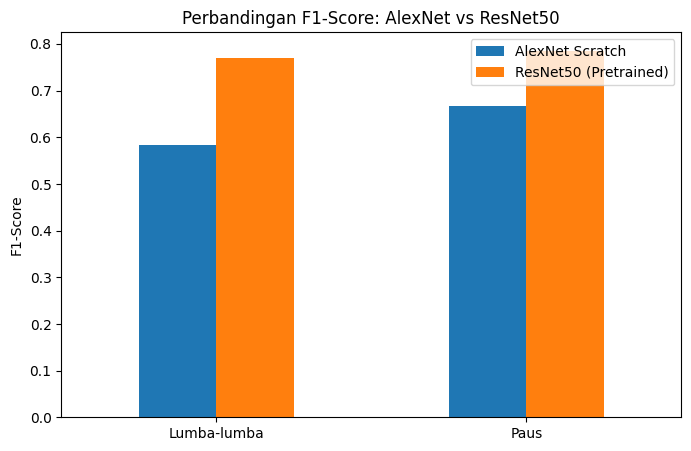

In [ ]:
# Grouped bar chart of per-class F1-scores
# Write your code here

f1_alex = f1_score(y_true_alex, y_pred_alex, average=None)
f1_pre = f1_score(y_true_pre, y_pred_pre, average=None)

df = pd.DataFrame({
    'AlexNet Scratch': f1_alex,
    'ResNet50 (Pretrained)': f1_pre
}, index=['Lumba-lumba', 'Paus'])

df.plot(kind='bar', figsize=(8, 5))
plt.title('Perbandingan F1-Score: AlexNet vs ResNet50')
plt.ylabel('F1-Score')
plt.xticks(rotation=0)
plt.show()

Berdasarkan grafik perbandingan F1-Score di atas, kelas yang paling diuntungkan Kelas Lumba-lumba adalah yang paling diuntungkan saat beralih dari AlexNet *scratch* ke *pretrained model* adalah kelas Lumba-lumba (kelas 0). Nilai F1-Score untuk kelas Lumba-lumba mengalami kenaikan yang paling signifikan, yaitu dari sekitar 0.58 menjadi sekitar 0.77. Adanya selisih peningkatan sekitar 0.19. Adapun untuk kelas Paus, peningkatan nilai F1-Scorenya lebih moderat, yaitu dari sekitar 0.67 menjadi sekitar 0.79 dengan selisih peningkatan hanya sekitar 0.12. Alasan *pretrained model* jauh lebih baik daripada model AlexNet *scratch* dalam kasus ini di antaranya adalah model ResNet50 sudah pintar mengekstrak fitur visual karena telah dilatih sebelumnya menggunakan jutaan gambar. Sementara itu, model AlexNet harus menebak dan mempelajari semuanya dari awal menggunakan dataset kecil yang sangat rentan *overfitting* karena model sekadar menghafal gambar *training*.

### 4.4 Analisis Bias-Variance

Analisis bias-variance: model mana yang menunjukkan underfitting? Overfitting? Gunakan learning curve sebagai bukti.

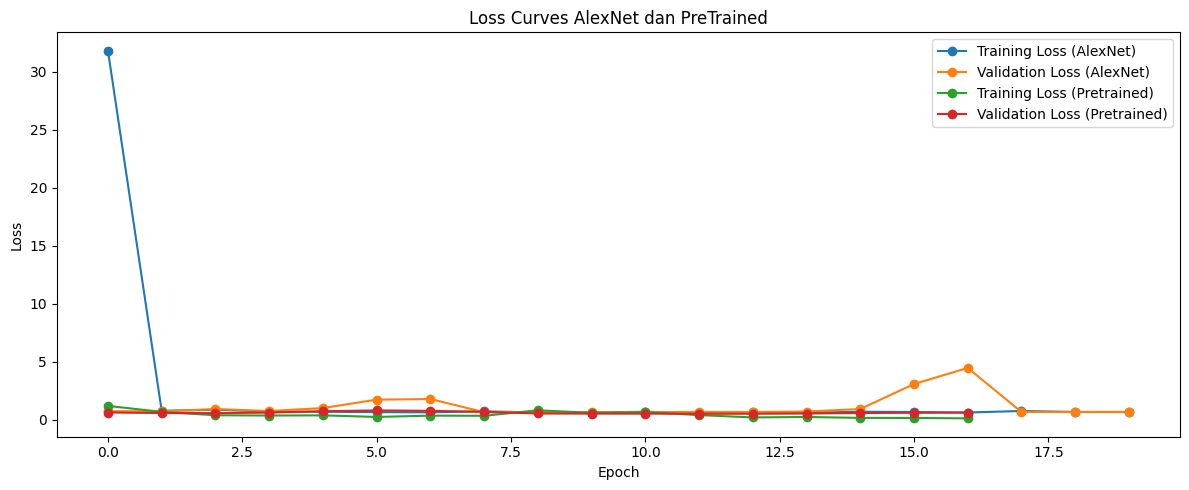

In [ ]:
# Plot both loss curves in a single figure for easy comparison
# Write your code here

plt.figure(figsize=(12, 5))

plt.plot(history.history['loss'], label='Training Loss (AlexNet)', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss (AlexNet)', marker='o')
plt.plot(total_loss, label='Training Loss (Pretrained)', marker='o')
plt.plot(total_val_loss, label='Validation Loss (Pretrained)', marker='o')
plt.title('Loss Curves AlexNet dan PreTrained')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

Berdasarkan grafik *learning curve* di atas, model yang mengalami *overfitting* adalah model AlexNet Scratch dan model yang mengalami *well-fitted* adalah model PreTrained. Tidak ada model yang mengalami *underfitting* dalam kasus ini. Perhatikan bahwa nilai *training loss* AlexNet langsung turun drastis mendekati nol sejak *epoch* pertama dan terus datar di bawah. Akan tetapi, nilai *validation loss*-nya tidak ikut stabil di bawah, melainkan berfluktuasi dan mengalami lonjakan yang tinggi. Jarak yang semakin lebar antara *training loss* dan *validation loss* yang tinggi atau berfluktuasi merupakan ciri khas *overfitting*. Di sisi lain, model *PreTrained* menunjukkan kondisi *well-fitted*. Kedua garis *training loss* dan *validation loss* turun secara bersamaan, stabil, dan posisinya berhimpit pada nilai *loss* yang rendah. Tidak ada model yang menunjukkan *underfitting* pada kasus ini. Ciri utama *underfitting* adalah nilai *training loss* tertahan pada nilai yang tinggi dan gagal turun meskipun *epoch* bertambah. Pada kasus ini, nilai *training loss* untuk kedua model berhasil turun hingga mendekati angka 0.

### 4.5 Trade-off: Transfer Learning vs. Training from Scratch

Apakah penggunaan *transfer learning* (*pre-trained model*) selalu memberikan performa lebih baik pada dataset ini? Diskusikan *trade-off* antara kompleksitas model, waktu *training*, dan akurasi yang didapat.


Pada dataset ini, penggunaan *transfer learning* memberikan performa lebih baik. Hal ini disebabkan oleh dataset berupa gambar hewan, fiturnya sudah dikenali oleh model yang dilatih di ImageNet, sehingga penggunaan *transfer learning* jauh lebih menguntungkan daripada melatih dari nol. Namun, dalam praktiknya, pemilihan antara kedua metode ini selalu melibatkan *trade-off* pada tiga aspek utama sebagai berikut.
- **Kompleksitas Model**: Model *PreTrained* sangat kompleks sehingga memakan memori dan ukurannya berat. Sementara itu, model AlexNet Scratch lebih sederhana dan ringan sehingga memakan memori yang lebih kecil.

- **Waktu *Training*** : Model *PreTrained* hanya butuh sedikit *epoch* atau lebih cepat konvergen. Akan tetapi, karena arsitekturnya lebih besar, waktu komputasi per *epoch*-nya lebih lama jika hardware yang digunakan kurang memadai. Sementara itu, model AlexNet Scratch membutuhkan waktu komputasi per *epoch* lebih cepat. Namun, ia membutuhkan lebih banyak *epoch* menuju kekonvergenan yang membuat total waktu *training* menjadi lebih lama.

- **Akurasi**: Model *PreTrained* memberikan akurasi dan F1-score yang jauh lebih tinggi karena sudah punya pengetahuan dasar tentang gambar, sehingga sangat baik dalam generalisasi. Sementara itu, model AlexNet Scratch akurasinya lebih rendah dan sangat rentan terhadap *overfitting* karena model harus menebak fitur dari awal menggunakan jumlah data yang terbatas.

---
# 5. Insights

Untuk setiap tahap yang dilakukan, sebutkan insight yang didapatkan selama pengerjaan praktikum. Insight yang dimaksud adalah analisis dan juga argumen pendukung terhadap setiap tahap yang dilakukan.

### 5.1 Insight EDA

*Write your insights here*

### 5.2 Insight Data Preprocessing

*Write your insights here*

### 5.3 Insight Modeling and Validation

Model AlexNet yang arsitekturnya memenangkan kompetisi ImageNet ternyata dalam kasus ini tidak menghasilkan performa yang serupa. Hal ini diakibatkan model AlexNet Scratch kita tidak dilatih dengan dataset besar seperti pada kompetisi tersebut yang dilatih dengan jutaan gambar. Namun, pada kasus kita, jumlah parameter yang dilatih sangat besar, puluhan juta harus dilatih dengan kurang lebih 100 gambar, akibatnya model AlexNet mengalami *overfitting*. Sebaliknya, dengan model *PreTrained* yang sebelumnya dilatih dengan jutaan gambar, menghasilkan performa lebih baik. Dengan demikian, kita perlu melatih model Convolutional Neural Network dengan dataset yang besar.

### 5.4 Insight Analysis

Model yang dilatih dari awal dengan dataset kecil rawan mengalami *overfitting*. Adapun model yang sudah memiliki pengetahuan pada pembelajaran sebelumnya lebih baik dalam menggeneralisasi dataset baru. Selain itu, melihat perbedaan nilai *training loss* dengan *validation loss* pada akhir training saja bisa menipu. Alangkah baiknya, kita meninjau nilai *loss* secara menyeluruh. Di sisi lain, pemilihan metode yang digunakan selalu menghasilkan *trade-off* yang perlu dipertimbangkan, terutama kompleksitas model, akurasi, dan waktu *training*. Hal ini penting untuk pengembangan dan *deployment* model selanjutnya.

---
# 6. Submisi Kaggle

**Submisi dibatasi 20 kali. Submisi final harus *reproducible*.**

Format penamaan kelompok di Kaggle: `Kelas_NomorKelompok_NamaKelompok` (Contoh: K1_99_gAIB21)

In [ ]:
import os
import numpy as np
import pandas as pd
from tensorflow.keras.preprocessing.image import load_img, img_to_array

test_folder_path = '/content/drive/MyDrive/PrakML3/test'
test_filenames = sorted([f for f in os.listdir(test_folder_path) if f.endswith(('.jpg', '.png', '.jpeg', '.gif'))])
best_model = pretrained_model

all_preds = []
file_ids = []

for fname in test_filenames:
    img_path = os.path.join(test_folder_path, fname)
    img = load_img(img_path, target_size=(224, 224))
    img_array = np.expand_dims(img_to_array(img), axis=0) / 255.0
    preds_prob = best_model.predict(img_array, verbose=0)
    pred_label = np.argmax(preds_prob, axis=1)[0]
    all_preds.append(pred_label)
    file_ids.append(os.path.splitext(fname)[0])

submission = pd.DataFrame({'File_ID': file_ids, 'Label': all_preds})
submission.to_csv('submission.csv', index=False)

print(submission)

                                 File_ID  Label
0   02d42cdd-260c-4992-93a2-7c44e629d2ef      0
1   0a2a7961-10b0-43db-899d-93eaaa31e41d      0
2   129f9b5b-2bdd-4010-aad7-f05bdd86b55b      0
3   147fede4-2fa0-45a4-81cb-a71bc677f289      0
4   18182b53-e1e5-4931-b20b-541075059a9b      0
5   1aa54989-8e13-4a38-8a6a-902cb5f70de3      0
6   253e7bf7-27db-4cb2-8a53-0f7ce4c8dada      1
7   29386e84-8472-4941-8f53-d6f15a1e46a8      0
8   2b518fee-dec6-4258-b894-682721fa173c      0
9   2ccb79e9-ddbf-4daf-a8be-bbf4b85fecd9      0
10  300aed84-ef33-4b31-ae7e-2bd81900da76      0
11  3285c474-eb03-438e-9aeb-1f0305ed804c      0
12  34e3c78d-5e61-481d-b6b6-84627da046b7      0
13  3b73c0bf-6a8f-4d85-9aa0-ac9e6666db8d      0
14  3cfc4ad7-56f1-44ab-bf97-c741028517c2      0
15  3d1d423b-b014-4aff-854f-90d148977262      1
16  3f70726a-0989-4b6b-867a-70e300132aa0      0
17  4827c8fe-c3c3-4997-b7d8-8ecc30d8ffe5      0
18  4a96a06e-5132-457a-9871-c3c0b5fa8f1e      0
19  4b445683-3b0f-4e1a-9fe2-a06b8f55fd20

Mangat yak gess!

\- Asisten